   Student_ID  Age  Study_Hours  Attendance  Assignments_Score  Exam_Score  \
0           1   18            5          92                 85          88   
1           2   19            7          95                 90          94   
2           3   18            3          78                 70          72   
3           4   20            8          98                 94          96   
4           5   19            6          89                 82          85   

               Department  Gender  
0        Computer Science    Male  
1  Information Technology  Female  
2        Computer Science  Female  
3             Electronics    Male  
4              Mechanical    Male  
(50, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Student_ID         50 non-null     int64 
 1   Age                50 non-null     int64 
 2   Study_Hours 

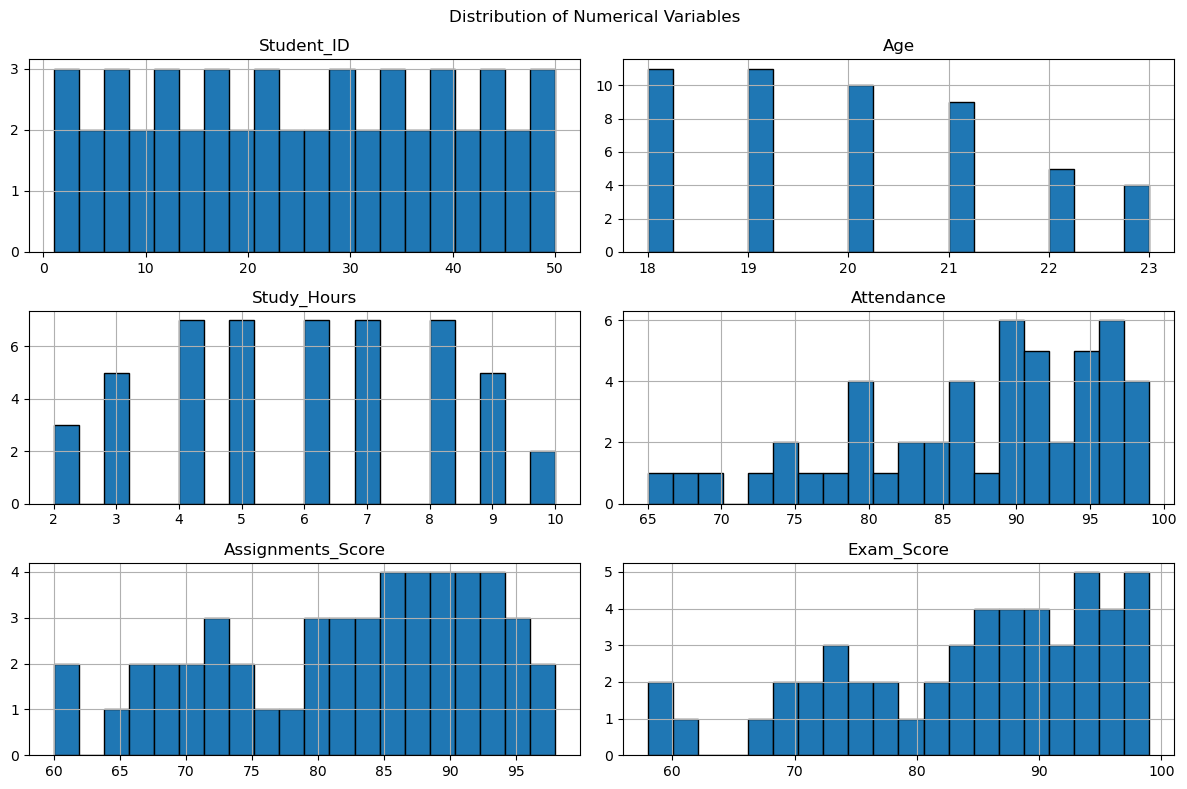

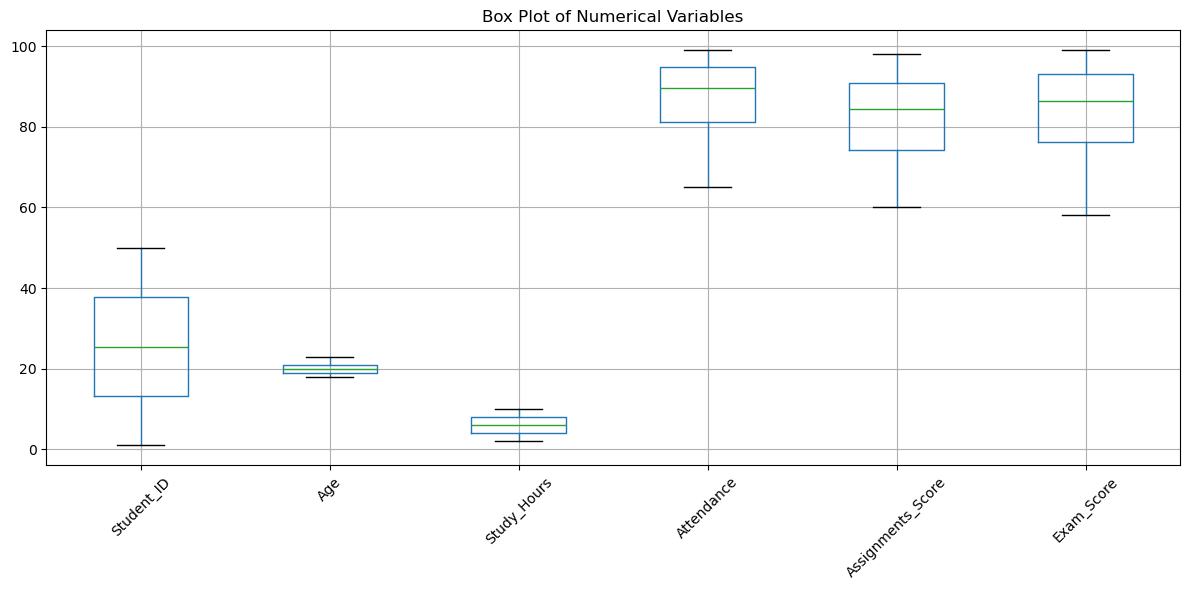


Correlation Matrix:
                   Student_ID       Age  Study_Hours  Attendance  \
Student_ID           1.000000  0.137815     0.059502    0.021079   
Age                  0.137815  1.000000     0.423745    0.373200   
Study_Hours          0.059502  0.423745     1.000000    0.955297   
Attendance           0.021079  0.373200     0.955297    1.000000   
Assignments_Score    0.015080  0.409895     0.976538    0.990252   
Exam_Score           0.020410  0.399330     0.966358    0.995366   

                   Assignments_Score  Exam_Score  
Student_ID                  0.015080    0.020410  
Age                         0.409895    0.399330  
Study_Hours                 0.976538    0.966358  
Attendance                  0.990252    0.995366  
Assignments_Score           1.000000    0.995099  
Exam_Score                  0.995099    1.000000  


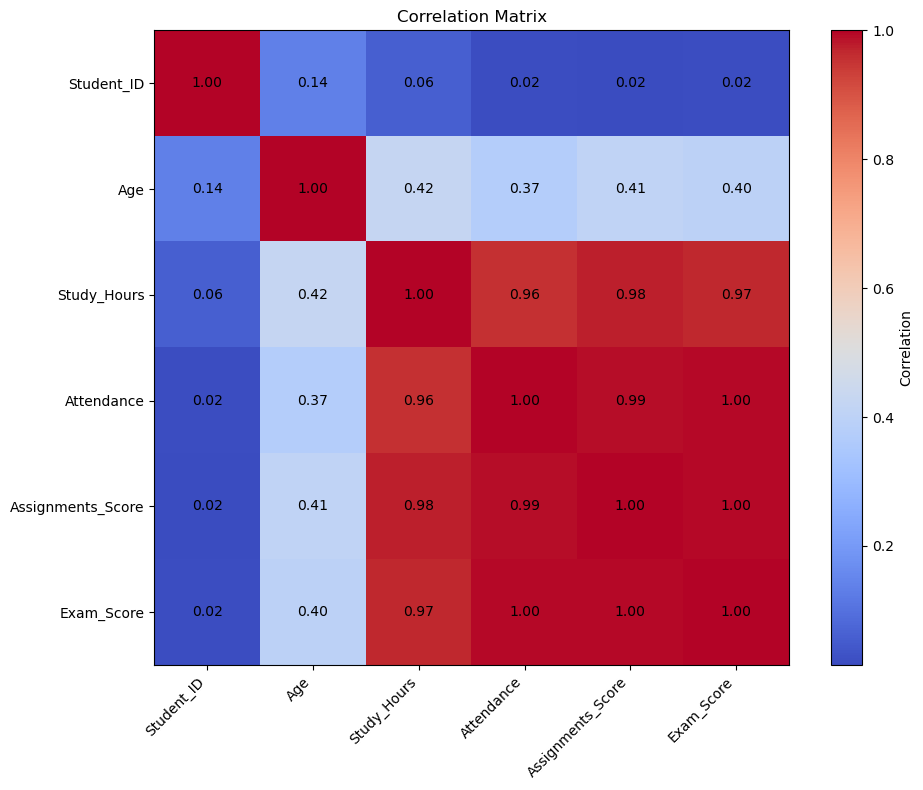

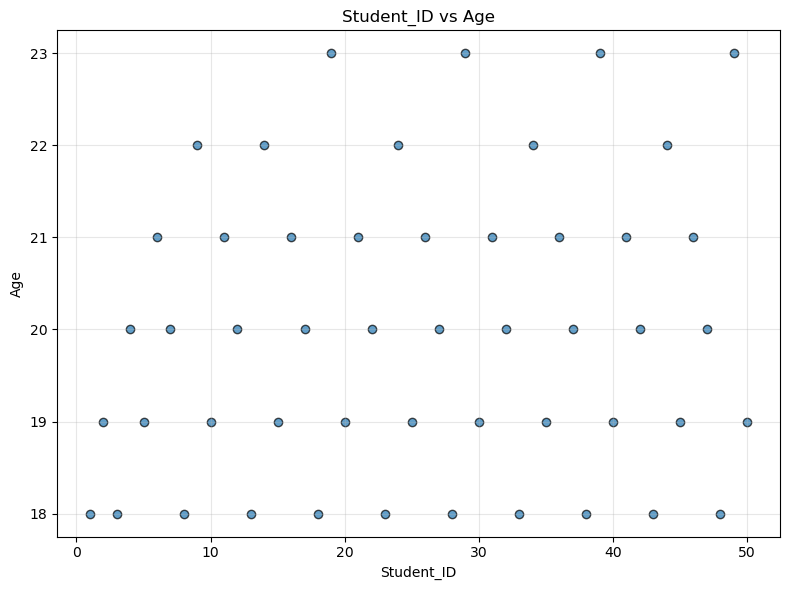


Department
Department
Computer Science          11
Information Technology    10
Electronics               10
Mechanical                10
Civil                      9
Name: count, dtype: int64

Gender
Gender
Female    26
Male      24
Name: count, dtype: int64

Final dataset shape: (50, 8)

EDA completed successfully!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("DATASET.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.dtypes)

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("\nMissing values:")
print(df.isnull().sum())

numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(exclude=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

for column in categorical_columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nSummary statistics:")
print(df.describe())

for column in numeric_columns:
    values = df[column].to_numpy()
    print(f"\n{column}")
    print("Mean:", np.mean(values))
    print("Median:", np.median(values))
    print("Standard Deviation:", np.std(values))
    print("Minimum:", np.min(values))
    print("Maximum:", np.max(values))

df[numeric_columns].hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
df[numeric_columns].boxplot()
plt.title("Box Plot of Numerical Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

correlation_matrix = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

if len(numeric_columns) >= 2:
    x_column = numeric_columns[0]
    y_column = numeric_columns[1]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        df[x_column],
        df[y_column],
        alpha=0.7,
        edgecolors="black"
    )

    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"{x_column} vs {y_column}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())

print("\nFinal dataset shape:", df.shape)
print("\nEDA completed successfully!")